<a href="https://colab.research.google.com/github/Jmontoyaor/SignalsandSystems-/blob/main/TALLER_2_JUANFERNANDOMONTOYA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller 2
## Juan Fernando Montoya Ortiz


Explique las semejanzas y diferencias entre la serie de Fourier (exponencial, trigonometrica y compacta), la transformada de Fourier, transformada de Fourier en tiempo discreto (DTFT) y transformada discreta de Fourier (DFT). Consi
dere las diferentes combinaciones entre: espectro continuo y
 discreto y señal en tiempo continuo y discreto. Además, con
sulte en que consiste el algoritmo Fast Fourier Transform
(FFT) y su utilidad para el calculo de la transformada dis
creta de Fourier. Explique en detalle el algoritmo FFT y su
 costo computacional vs el de la transformada discreta. Ver
 cuaderno Transformada de Fourier.

Semejanzas y Diferencias de las Transformadas de Fourier

El análisis de Fourier se basa en la idea de que cualquier señal (función) puede ser representada como una suma de senoides (ondas sinusoidales y cosinusoidales) de diferentes frecuencias y amplitudes. Las diferentes variantes de la transformada de Fourier surgen al considerar si la señal original está en tiempo continuo o discreto, y si el espectro resultante es continuo o discreto.

Observaciones Adicionales:

Serie de Fourier: Representa una señal periódica en el dominio del tiempo continuo como una suma de exponenciales complejos (forma exponencial) o senoides (formas trigonométrica y compacta) con frecuencias que son múltiplos enteros de la frecuencia fundamental de la señal. El espectro es discreto, mostrando la amplitud de cada componente armónica.
Transformada de Fourier (Continua): Se aplica a señales no periódicas en el dominio del tiempo continuo. El resultado es un espectro continuo, que indica la distribución de frecuencias presentes en la señal.
Transformada de Fourier en Tiempo Discreto (DTFT): Se aplica a señales discretas en el tiempo que no son periódicas. El espectro resultante es continuo y periódico. [1] describe que el DTFT es una suma periódica del transformado original.
Transformada Discreta de Fourier (DFT): Se aplica a señales discretas y periódicas en el tiempo, o a un conjunto finito de muestras de una señal. El espectro resultante también es discreto. La DFT se puede entender como el cálculo de muestras discretas del DTFT continuo. [1] menciona que el DFT calcula muestras discretas del DTFT continuo.

lgoritmo Fast Fourier Transform (FFT)

El algoritmo Fast Fourier Transform (FFT) es un algoritmo computacionalmente eficiente para calcular la Transformada Discreta de Fourier (DFT) y su inversa. Fue popularizado por Cooley y Tukey en 1965.

Utilidad para el Cálculo de la DFT:

La DFT directa implica calcular una suma de términos para cada punto en el espectro de frecuencia. Este cálculo directo tiene un costo computacional elevado, especialmente para señales largas. La FFT reduce drásticamente el número de operaciones requeridas para calcular la DFT, lo que la hace práctica para el análisis de señales en tiempo real y otras aplicaciones con grandes conjuntos de datos.

Explicación Detallada del Algoritmo FFT:

La FFT utiliza un enfoque de "divide y vencerás". La idea principal es descomponer una DFT de tamaño N en DFTs más pequeñas. Hay varias implementaciones de la FFT, pero la más común es la FFT radix-2, que requiere que el tamaño N de la señal sea una potencia de 2.

El principio de la FFT radix-2 se basa en dividir la secuencia de entrada en dos sub-secuencias: una con los elementos de índice par y otra con los elementos de índice impar. La DFT de tamaño N se puede expresar en términos de las DFTs de tamaño N/2 de estas dos sub-secuencias. Este proceso se repite recursivamente hasta que se obtienen DFTs de tamaño 1, que son triviales de calcular. Los resultados de las DFTs más pequeñas se combinan luego de manera eficiente para obtener la DFT de tamaño N.

La "mariposa" es una representación gráfica común de la operación básica dentro del algoritmo FFT, donde las salidas de las DFTs de tamaño más pequeño se combinan para calcular las entradas de la siguiente etapa.

Costo Computacional:

DFT Directa: El cálculo directo de la DFT requiere aproximadamente $O(N^2)$$O(N^2)$ operaciones (multiplicaciones y sumas), donde N es el número de muestras.
FFT (radix-2): El algoritmo FFT radix-2 reduce el costo computacional a aproximadamente $O(N \log_2(N))$$O(N \log_2(N))$ operaciones.
Comparación del Costo Computacional:

La diferencia en el costo computacional es significativa, especialmente para valores grandes de N. Por ejemplo, para N = 1024 (una potencia de 2), la DFT directa requiere aproximadamente $1024^2 = 1,048,576$$1024^2 = 1,048,576$ operaciones, mientras que la FFT requiere aproximadamente $1024 \times \log_2(1024) = 1024 \times 10 = 10,240$$1024 \times \log_2(1024) = 1024 \times 10 = 10,240$ operaciones. Esto demuestra la enorme eficiencia de la FFT en comparación con el cálculo directo de la DFT.

En resumen, la FFT es un algoritmo fundamental en el procesamiento digital de señales y otras áreas, ya que permite calcular la DFT de manera mucho más rápida y eficiente.

#Modulacion AM

📚 ¿Qué es la modulación AM con detección coherente?
La modulación AM (amplitud modulada) es un proceso donde se transmite una señal de baja frecuencia (el mensaje) variando la amplitud de una portadora de alta frecuencia.

En la detección coherente, el receptor tiene acceso a una réplica sincronizada de la portadora original. Esto permite recuperar el mensaje multiplicando la señal recibida por esa portadora y luego filtrando.

📌 Ventajas de la detección coherente:

Mayor precisión en la recuperación del mensaje.

Mejora del desempeño en canales ruidosos.

📌 Aplicaciones:

Comunicaciones de radio AM.

Transmisión de voz en radiofrecuencia.

Modulación en sistemas de radar y sensores.

Introduce el índice de modulación (ej. 0.5 para 50%, 1.0 para 100%): 0.5


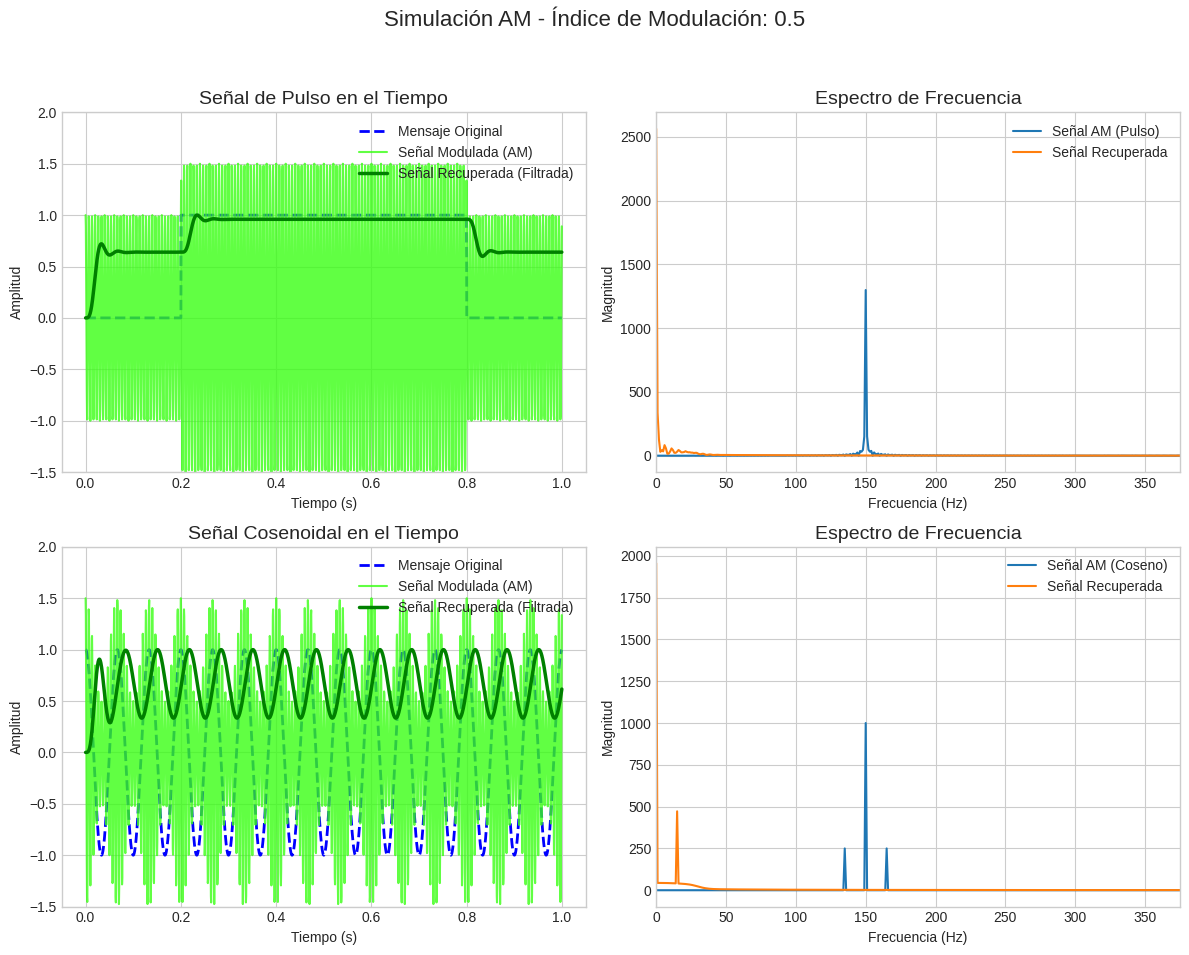

In [1]:
# -*- coding: utf-8 -*-
"""
Simulación de Modulación de Amplitud (AM) con Detección Coherente
Este script ilustra la modulación y demodulación de señales
usando una portadora senoidal.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import butter, lfilter

# --- 1. Configuración de la Simulación ---
DURACION = 1.0  # Duración de la señal en segundos
FREC_MUESTREO = 2000  # Frecuencia de muestreo en Hz (mayor para mejor resolución)
N_MUESTRAS = int(DURACION * FREC_MUESTREO)
tiempo = np.linspace(0, DURACION, N_MUESTRAS, endpoint=False)

# Frecuencias para las señales
frec_portadora = 150.0  # Frecuencia de la portadora en Hz
frec_mensaje_cos = 15.0   # Frecuencia del mensaje cosenoidal

# --- 2. Entrada del Usuario ---
while True:
    try:
        mu_input = input("Introduce el índice de modulación (ej. 0.5 para 50%, 1.0 para 100%): ")
        indice_modulacion = float(mu_input)
        if 0 < indice_modulacion:
            break
        else:
            print("Por favor, introduce un valor positivo.")
    except ValueError:
        print("Entrada no válida. Por favor, introduce un número.")

# --- 3. Funciones para la Simulación ---

def disenar_filtro_paso_bajo(frec_corte, frec_muestreo, orden=5):
    """Diseña un filtro Butterworth paso bajo."""
    nyquist = 0.5 * frec_muestreo
    normal_cutoff = frec_corte / nyquist
    b, a = butter(orden, normal_cutoff, btype='low', analog=False)
    return b, a

def aplicar_filtro(datos, b, a):
    """Aplica un filtro a una señal."""
    return lfilter(b, a, datos)

def modular_am(mensaje, frec_portadora, tiempo, mu):
    """Genera la señal AM."""
    # Normalizar el mensaje para que su amplitud máxima sea 1
    mensaje_normalizado = mensaje / np.max(np.abs(mensaje))
    # La señal AM se define como (1 + mu * m(t)) * Ac * cos(2*pi*fc*t)
    # Por simplicidad, se asume una amplitud de portadora (Ac) de 1.
    return (1 + mu * mensaje_normalizado) * np.cos(2 * np.pi * frec_portadora * tiempo)

def demodular_coherentemente(senal_am, frec_portadora, tiempo, filtro_b, filtro_a):
    """Realiza la demodulación coherente (multiplicación + filtrado)."""
    # Multiplicar por el oscilador local (sincronizado)
    senal_multiplicada = senal_am * np.cos(2 * np.pi * frec_portadora * tiempo)
    # Aplicar el filtro paso bajo para recuperar el mensaje
    senal_recuperada = aplicar_filtro(senal_multiplicada, filtro_b, filtro_a)
    return senal_recuperada

# --- 4. Generación de Señales ---

# Señal Mensaje 1: Pulso Rectangular
mensaje_pulso = np.zeros_like(tiempo)
mensaje_pulso[(tiempo > 0.2) & (tiempo < 0.8)] = 1.0

# Señal Mensaje 2: Cosenoidal
mensaje_coseno = np.cos(2 * np.pi * frec_mensaje_cos * tiempo)

# Diseño del filtro paso bajo (frecuencia de corte un poco mayor que la del mensaje)
filtro_b, filtro_a = disenar_filtro_paso_bajo(frec_corte=30, frec_muestreo=FREC_MUESTREO)

# --- 5. Proceso de Modulación y Demodulación ---

# Para el pulso rectangular
am_pulso = modular_am(mensaje_pulso, frec_portadora, tiempo, indice_modulacion)
recuperada_pulso = demodular_coherentemente(am_pulso, frec_portadora, tiempo, filtro_b, filtro_a)

# Para la señal cosenoidal
am_coseno = modular_am(mensaje_coseno, frec_portadora, tiempo, indice_modulacion)
recuperada_coseno = demodular_coherentemente(am_coseno, frec_portadora, tiempo, filtro_b, filtro_a)

# --- 6. Visualización de Resultados ---

def graficar_dominio_tiempo(t, msg, am_signal, recovered_signal, title):
    """Función para graficar las señales en el dominio del tiempo."""
    plt.plot(t, msg, 'b--', label='Mensaje Original', linewidth=2)
    plt.plot(t, am_signal, color='#39FF14', alpha=0.8, label='Señal Modulada (AM)', linewidth=1.5)
    # Se escala la señal recuperada para compararla visualmente con el mensaje original
    escala = np.max(np.abs(msg)) / np.max(np.abs(recovered_signal))
    plt.plot(t, recovered_signal * escala, 'g-', label='Señal Recuperada (Filtrada)', linewidth=2.5)
    plt.title(title, fontsize=14)
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True)
    plt.ylim(-1.5, 2.0) # Ajuste de límites para mejor visualización

def graficar_dominio_frecuencia(signal, fs, title):
    """Función para graficar el espectro de frecuencia."""
    N = len(signal)
    yf = rfft(signal)
    xf = rfftfreq(N, 1 / fs)
    plt.plot(xf, np.abs(yf), label=title)
    plt.title('Espectro de Frecuencia', fontsize=14)
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.grid(True)
    plt.xlim(0, frec_portadora * 2.5) # Limitar vista a frecuencias relevantes

# Creación de las figuras
plt.style.use('seaborn-v0_8-whitegrid')

# Gráficas para el mensaje de pulso
plt.figure(figsize=(12, 10))
plt.suptitle(f'Simulación AM - Índice de Modulación: {indice_modulacion}', fontsize=16)

# Tiempo
plt.subplot(2, 2, 1)
graficar_dominio_tiempo(tiempo, mensaje_pulso, am_pulso, recuperada_pulso, 'Señal de Pulso en el Tiempo')

# Frecuencia
plt.subplot(2, 2, 2)
graficar_dominio_frecuencia(am_pulso, FREC_MUESTREO, 'Señal AM (Pulso)')
graficar_dominio_frecuencia(recuperada_pulso * 2, FREC_MUESTREO, 'Señal Recuperada') # Se escala para verla
plt.legend()

# Gráficas para el mensaje cosenoidal
# Tiempo
plt.subplot(2, 2, 3)
graficar_dominio_tiempo(tiempo, mensaje_coseno, am_coseno, recuperada_coseno, 'Señal Cosenoidal en el Tiempo')

# Frecuencia
plt.subplot(2, 2, 4)
graficar_dominio_frecuencia(am_coseno, FREC_MUESTREO, 'Señal AM (Coseno)')
graficar_dominio_frecuencia(recuperada_coseno * 2, FREC_MUESTREO, 'Señal Recuperada') # Se escala para verla
plt.legend()


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **Aplicación en circuitos eléctricos – Potencia**

En este documento se abordarán los conceptos de **Distorsión Total Armónica (THD)** y **Factor de Potencia (FP)** en circuitos eléctricos. También se mostrará cómo calcular el THD a partir de la Transformada Rápida de Fourier (FFT) usando Python.

---

## 📘 **¿Qué es la distorsión total de armónicos (THD)?**

La **THD** cuantifica la cantidad de energía presente en los armónicos de una señal respecto a su componente fundamental.

\[
\text{THD} = \frac{\sqrt{V_2^2 + V_3^2 + V_4^2 + \dots}}{V_1}
\]

Donde:

- \( V_1 \) es la amplitud de la componente fundamental.
- \( V_n \) es la amplitud del armónico \( n \).

Expresado en porcentaje:

\[
\text{THD}_{\%} = \left( \frac{\sqrt{\sum_{n=2}^{N} V_n^2}}{V_1} \right) \times 100
\]

---

## ⚡ **¿Qué es el factor de potencia (FP)?**

El **Factor de Potencia (FP)** mide la eficiencia en el uso de la energía. Se define como:

\[
FP = \frac{P}{S}
\]

donde:
- \( P \): Potencia activa
- \( S \): Potencia aparente

Cuando hay distorsión, se calcula el **factor de potencia por distorsión**:

\[
FP_{\text{dist}} = \frac{1}{\sqrt{1 + \text{THD}^2}}
\]

---
### Ejemplo: Rectificador de Onda Completa
- ### Caso: Carga resistiva pura
  - Fuente AC: $V_o(t)=V_m \cdot \sin(\omega t)$

  - Frecuencia: $f=60\ \text{Hz}$

  - Carga: $R=150\ \Omega$

  Supongamos que la magnitud de la componente fundamental es $I_1 = 1.2\ \text{A}$, y que hay 4 armónicos superiores con las siguientes magnitudes:

  $I_2 = 0.15\ \text{A}$,

  $I_3 = 0.12\ \text{A}$,

  $I_4 = 0.08\ \text{A}$,

  $I_5 = 0.05\ \text{A}$

  Aplicando la fórmula del THD:

  $$
  THD = \frac{\sqrt{0.15^2 + 0.12^2 + 0.08^2 + 0.05^2}}{1.2}
  $$

  $$
  THD = \frac{\sqrt{0.0488}}{1.2}
  $$

  $$
  THD \approx \frac{0.2209}{1.2} \approx 0.184
  $$

  $$
  THD \approx 18.4\%
  $$

  Ahora usamos este valor para estimar el **factor de potencia por distorsión**:

  $$
  f.d.p = DPF \cdot \frac{1}{\sqrt{1 + 0.184^2}} \approx DPF \cdot 0.984
  $$

---

- ### Caso: Carga RL en Serie
  - Fuente AC: $V_o(t)=V_m \cdot \sin(\omega t)$

  - Frecuencia: $f=60\ \text{Hz}$

  - Carga: $R=100\ \Omega$, $L = 50\ \text{mH}$

  Supongamos:

  $I_1 = 0.9\ \text{A}$

  Armónicos superiores:

  $I_2 = 0.4\ \text{A}$,

  $I_3 = 0.35\ \text{A}$,

  $I_4 = 0.25\ \text{A}$,

  $I_5 = 0.2\ \text{A}$

  Cálculo de THD:

  $$
  THD = \frac{\sqrt{0.4^2 + 0.35^2 + 0.25^2 + 0.2^2}}{0.9}
  $$

  $$
  THD = \frac{\sqrt{0.485}}{0.9}
  $$

  $$
  THD \approx \frac{0.696}{0.9} \approx 0.773
  $$

  $$
  THD \approx 77.3\%
  $$

  Factor de potencia:

  $$
  f.d.p = DPF \cdot \frac{1}{\sqrt{1 + 0.773^2}} \approx DPF \cdot 0.79
  $$

---

Se observa que, en el caso de la carga puramente resistiva, aunque hay presencia de armónicos, la distorsión total es moderada y el factor de potencia se mantiene alto. En contraste, para la carga RL, la inductancia genera un desfase y provoca una forma de onda de corriente más distorsionada, reduciendo el factor de potencia.





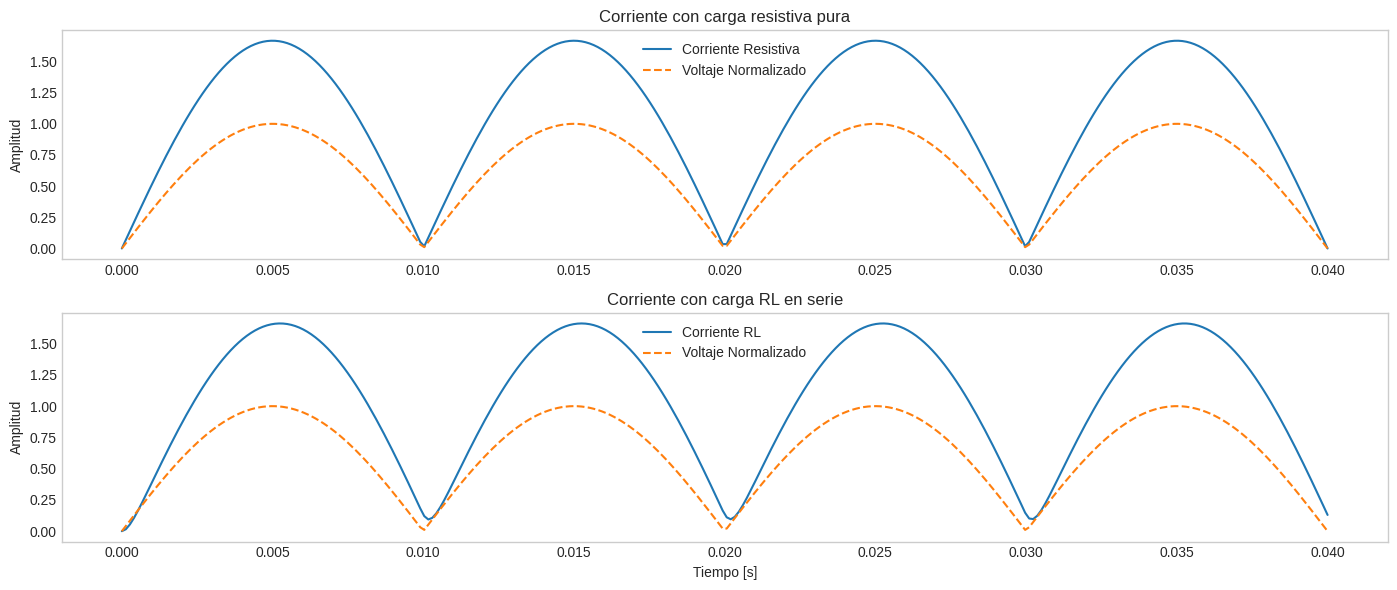

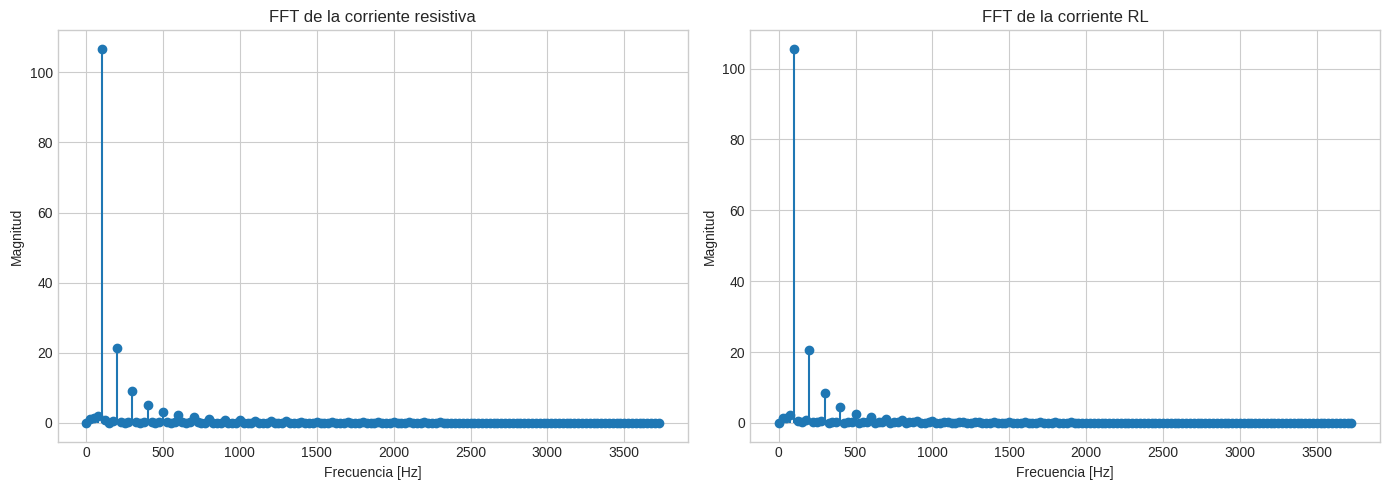

----- NUEVO EJEMPLO: THD Y FP -----
Carga Resistiva:
  THD: 22.81%
  Factor de Potencia: 1.0033

Carga RL en serie:
  THD: 21.83%
  Factor de Potencia: 1.0005


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import scipy
from scipy.signal import lti, lsim



# 1. Parámetros de la señal y el sistema
f = 50                    # Frecuencia de red [Hz]
w = 2 * np.pi * f         # Velocidad angular
Vm = 200                  # Voltaje pico (141 Vrms)
T = 1 / f                 # Periodo
t = np.linspace(0, 2*T, 300)  # Tiempo para 2 ciclos
fs = len(t) / (t[-1] - t[0])  # Frecuencia de muestreo

# Señal de entrada: seno ideal de 50 Hz
vin = Vm * np.sin(w * t)

# Rectificación de onda completa
vout = np.abs(vin)

# ------------------------------
# Funciones de análisis
# ------------------------------

def calcular_thd(signal, fs):
    N = len(signal)
    freqs = fftfreq(N, d=1/fs)
    fft_vals = np.abs(fft(signal))[:N//2]
    freqs = freqs[:N//2]
    fft_vals[0] = 0  # eliminar componente DC

    fundamental_index = np.argmax(fft_vals)
    V1 = fft_vals[fundamental_index]
    pot_total = np.sum(fft_vals**2)
    pot_harm = pot_total - V1**2
    thd = np.sqrt(pot_harm) / V1
    return thd, freqs, fft_vals

def calcular_fp(v, i):
    P_activa = scipy.integrate.simpson(v * i, t) / (t[-1] - t[0])
    Vrms = np.sqrt(np.mean(v**2))
    Irms = np.sqrt(np.mean(i**2))
    S_aparente = Vrms * Irms
    return P_activa / S_aparente

# ------------------------------
# i) CARGA NETAMENTE RESISTIVA
# ------------------------------
R = 120  # Ohmios
i_r = vout / R

thd_r, freqs_r, fft_r = calcular_thd(i_r, fs)
fp_r = calcular_fp(vout, i_r)

# ------------------------------
# ii) CARGA RL EN SERIE
# ------------------------------
L = 30e-3  # Henry
num = [1]
den = [L, R]
sistema = lti(num, den)

# Simular corriente con RL usando el voltaje rectificado como entrada
_, i_rl, _ = lsim(sistema, U=vout, T=t)

thd_rl, freqs_rl, fft_rl = calcular_thd(i_rl, fs)
fp_rl = calcular_fp(vout, i_rl)

# ------------------------------
# GRAFICAR RESULTADOS
# ------------------------------

plt.figure(figsize=(14, 6))

# Corriente resistiva
plt.subplot(2, 1, 1)
plt.plot(t, i_r, label='Corriente Resistiva')
plt.plot(t, vout / Vm, '--', label='Voltaje Normalizado')
plt.title("Corriente con carga resistiva pura")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()

# Corriente RL
plt.subplot(2, 1, 2)
plt.plot(t, i_rl, label='Corriente RL')
plt.plot(t, vout / Vm, '--', label='Voltaje Normalizado')
plt.title("Corriente con carga RL en serie")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------
# ESPECTROS FFT (Visualización)
# ------------------------------

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.stem(freqs_r, fft_r, basefmt=" ")
plt.title("FFT de la corriente resistiva")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.subplot(1, 2, 2)
plt.stem(freqs_rl, fft_rl, basefmt=" ")
plt.title("FFT de la corriente RL")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")

plt.tight_layout()
plt.show()

# ------------------------------
# MOSTRAR RESULTADOS
# ------------------------------

print("----- NUEVO EJEMPLO: THD Y FP -----")
print(f"Carga Resistiva:")
print(f"  THD: {thd_r*100:.2f}%")
print(f"  Factor de Potencia: {fp_r:.4f}")

print(f"\nCarga RL en serie:")
print(f"  THD: {thd_rl*100:.2f}%")
print(f"  Factor de Potencia: {fp_rl:.4f}")


In [3]:


#instalación de librerías
!pip install streamlit -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.9 MB/s eta 0:00:00


In [4]:
#instalar librerias necesarias para descargar audios youtube
!python3 -m pip install --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz -q
#Libreria para manipulacion de archivos de audio
!pip install soundfile -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 28.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
!pip install browser-cookie3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.9 MB/s eta 0:00:00


In [6]:
!apt install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [7]:
import gdown
import os

# Enlace de descarga directa, este es el modelo de youtube detector creado par los cuadernos de python guardados en github  lo que hace es comparame las cosas
url = 'https://drive.google.com/file/d/1hVOYLZXA1wTIKnPN79Ty7RohCdGTGrXd/view?usp=drive_link'

output_path = '/content/CAN/reggaeton_vs_metal.pkl'

# Crear la carpeta 'modelos' si no existe
output_dir = os.path.dirname(output_path)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Descargar el archivo
gdown.download(url, output_path, quiet=False)

/usr/local/lib/python3.11/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=1hVOYLZXA1wTIKnPN79Ty7RohCdGTGrXd
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1hVOYLZXA1wTIKnPN79Ty7RohCdGTGrXd/view?usp=drive_link
To: /content/CAN/reggaeton_vs_metal.pkl
8.92kB [00:00, 4.56MB/s]


'/content/CAN/reggaeton_vs_metal.pkl'

In [8]:
import os

output_path = '/content/CAN/reggaeton_vs_metal.pkl'

if os.path.exists(output_path):
    print(f"File downloaded successfully to: {output_path}")
else:
    print(f"File not found at: {output_path}. Download might have failed.")

File downloaded successfully to: /content/CAN/reggaeton_vs_metal.pkl


In [9]:
import os

# Verificar los archivos dentro de la carpeta '/content/'
os.listdir('/content/CAN/')

['reggaeton_vs_metal.pkl']

In [10]:
!mkdir pages

In [29]:
%%writefile GenreSense.py
import streamlit as st
import numpy as np
import librosa
import yt_dlp
import soundfile as sf
import os
import matplotlib.pyplot as plt
import joblib
import tempfile
import subprocess
import time
from sklearn.preprocessing import MinMaxScaler
import browser_cookie3
import gdown # Import gdown for downloading from Google Drive
import pandas as pd # Import pandas to read the excel file




# --- Configuración de la Página ---
st.set_page_config(
    page_title="GenreSense",
    page_icon="https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/icono.png",
    layout="wide"
)

# --- CSS Personalizado ---
st.markdown("""
<link href="https://fonts.googleapis.com/css2?family=Poppins&display=swap" rel="stylesheet">
""", unsafe_allow_html=True)
custom_css = """
<style>
    /* Estilos generales y del tema oscuro */
    .stApp {
        background-color: #0E0E0E;
        color: #F0F0F0;
        font-family: 'Poppins', sans-serif;
    }
    h1, h2, h3 {
        color: #D72638;
        text-shadow: 1px 1px 2px rgba(0, 0, 0, 0.5);
    }
    .main .block-container {
        padding-top: 2rem;
        padding-bottom: 2rem;
        background-color: #1A1A1A;
        border-radius: 10px;
    }
    section[data-testid="stSidebar"] {
        background-color: #121212;
        color: #FFFFFF;
        border-left: 4px solid #D72638;
        border-radius: 10px;
    }
    section[data-testid="stSidebar"] * {
        color: #FFFFFF !important;
    }
    .st-expander, .st-expander header {
        border-color: #D72638 !important;
        background-color: rgba(215, 38, 56, 0.1);
        border-radius: 10px;
    }
    hr {
        background-color: #D72638;
        height: 2px;
        border: none;
        margin: 1.5rem 0;
    }
    .stButton>button {
        background-color: #D72638;
        color: #FFFFFF;
        border-radius: 8px;
        border: none;
    }
    .stButton>button:hover {
        background-color: #FF4C4C;
        color: #FFFFFF;
    }
</style>
"""
st.markdown(custom_css, unsafe_allow_html=True)

# --- Encabezado y Título ---
col_img, col_title = st.columns([0.2, 1])
with col_img:
    st.image("https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/Mu%C3%B1eco.png", width=200)
with col_title:
    st.title("GenreSense: Detector de Género Musical")
st.markdown("#### ¿Qué género musical predomina en tu video favorito? ¡Descúbrelo ahora!")
st.write("---")




# --- Sidebar para configuración ---
with st.sidebar:
    st.header("Configuración de Análisis")
    st.slider("Tiempo inicial (segundos)", 0, 300, 30, key='start_time_slider', help="Punto de inicio para el análisis.")
    st.slider("Duración del segmento (segundos)", 5, 30, 10, key='segment_duration_slider', help="Duración del fragmento a analizar.")
    st.markdown("---")
    st.info("Señales y Sistemas | 2025")
    with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )


# --- Cargar modelo (cacheado) ---
@st.cache_resource
def load_model():
    try:
        # Asumiendo que el modelo se llama 'modelo.pkl'
        # Asegúrate de que la ruta y el nombre del archivo sean correctos
        model_path = '/content/CAN/reggaeton_vs_metal.pkl'
        if os.path.exists(model_path):
            model_data = joblib.load(model_path)
            # --- REMOVED DEBUGGING LINES ---
            # st.write("Tipo de model_data['modelo']:", type(model_data.get('modelo')))
            # st.write("Atributos de model_data['modelo']:", dir(model_data.get('modelo')))
            # -------------------------------
            return model_data
        else:
            st.error(f"Error: El archivo del modelo no se encuentra en la ruta esperada: {model_path}")
            return None
    except Exception as e:
        st.error(f"Error cargando el modelo: {e}")
        return None

model_data = load_model()

if model_data is None:
    st.warning("No se pudo cargar el modelo. La aplicación no funcionará correctamente.")
    # st.stop() # No detener completamente, solo mostrar advertencia


# Funciones de procesamiento de audio

# Función para descargar cookies del navegador
try:
    cookies = browser_cookie3.firefox()
except:
    print("No se pueden descargar cookies desde firefox. Intentando Chrome...")
    try:
        cookies = browser_cookie3.chrome()
    except:
        print("No se pueden descargar cookies desde Chrome. Por favor asegúrate de estar logueado en Youtube desde tu navegador.")
        cookies = None

#funcion para descargar mp3 desde youtube
def download_ytvid_as_mp3(video_url,name):
    #video_url = input("enter url of youtube video:")
    options={
        'format':'bestaudio/best',
        'keepvideo':False,
        'outtmpl':f'{name}.mp3',
        'quiet': True, # Added quiet and no_warnings for cleaner output
        'no_warnings': True,
    }
    if cookies:
        options['cookiefile'] = None
        options['cookiejar'] = cookies;

    try:
        # Corrected the usage of youtube_dl to use yt_dlp
        with yt_dlp.YoutubeDL(options) as ydl:
            video_info = ydl.extract_info(video_url, download=False)
            ydl.download([video_info['webpage_url']])
            # The original code had a typo here 'filename', changed to f'{name}.mp3'
            st.success(f"Download complete... {name}.mp3")
            return f"{name}.mp3" # Return the downloaded file path
    except Exception as e:
        st.error(f"Error descargando {video_url}: {e}")
        return None

def convert_to_wav(input_file):
    """Convierte un archivo de audio a WAV y devuelve la ruta del archivo WAV temporal"""
    # Usar tempfile para un nombre único de archivo de output WAV
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp_wav:
        wav_file = tmp_wav.name

    try:
        subprocess.run([
            'ffmpeg', '-y', '-i', input_file,
            '-ac', '2', '-ar', '48000',  # Estéreo, 48kHz
            wav_file
        ], check=True, capture_output=True, text=True)
        return wav_file
    except subprocess.CalledProcessError as e:
        st.error(f"Error convirtiendo a WAV: {e.stderr}")
        # Limpiar archivo temporal WAV si se creó parcialmente
        if os.path.exists(wav_file):
             os.unlink(wav_file)
        return None
    except Exception as e:
        st.error(f"Error inesperado durante la conversión a WAV: {e}")
        # Limpiar archivo temporal WAV si se creó parcialmente
        if os.path.exists(wav_file):
             os.unlink(wav_file)
        return None


def process_audio(audio_path, start_time, duration):
    """Procesa un segmento de audio y devuelve los datos y tasa de muestreo"""
    try:
        audio_data, sr = sf.read(audio_path)

        start_sample = int(start_time * sr)
        end_sample = int((start_time + duration) * sr)

        if end_sample > len(audio_data):
            st.warning(f"El audio es demasiado corto para el segmento seleccionado. Se analizará hasta el final del audio.")
            end_sample = len(audio_data)
            if start_sample >= end_sample:
                st.error("El tiempo de inicio es mayor o igual a la duración total del audio.")
                return None, None


        segment = audio_data[start_sample:end_sample]

        # Convertir a estéreo si es mono
        if segment.ndim == 1:
            segment = np.column_stack((segment, segment))

        return segment, sr
    except Exception as e:
        st.error(f"Error procesando el audio: {e}")
        return None, None


def compute_fft(audio_segment, sr):
    """Calcula la FFT y devuelve frecuencias y magnitudes normalizadas"""
    try:
        # Calcular FFT
        fft_result = np.fft.rfft(audio_segment, axis=0)
        fft_magnitude = np.abs(fft_result.mean(axis=1))  # Promedio de canales

        # Normalizar
        # Verificar si fft_magnitude tiene suficientes datos para la normalización
        if len(fft_magnitude.shape) == 1:
             fft_magnitude = fft_magnitude.reshape(-1, 1)

        scaler = MinMaxScaler()
        fft_normalized = scaler.fit_transform(fft_magnitude).flatten()

        freqs = np.fft.rfftfreq(len(audio_segment), 1/sr)

        return freqs, fft_normalized
    except Exception as e:
        st.error(f"Error calculando FFT: {e}")
        return None, None



##### hasta aqui##


# --- Layout Principal ---
col1, col2 = st.columns([1, 1.2], gap="large")

with col1:
    st.markdown(
        """
        ### ¡Bienvenido al Detector de Género Musical!
        Esta aplicación analiza el audio de un video de YouTube o un archivo local para predecir si su género musical es **Pop** o **Rock**.

        #### ¿Cómo funciona?
        1.  **Ingresa la fuente:** En la columna de la derecha, pega una URL de YouTube o sube un archivo de audio.
        2.  **Configura el análisis:** Usa los controles en la barra lateral para definir el segmento a analizar.
        3.  **Procesamiento:** La aplicación extrae el audio y calcula el espectro de frecuencia del segmento (usando FFT).
        4.  **Clasificación:** Un modelo de Machine Learning analiza el espectro y predice el género.
        5.  **Visualización:** Se muestra el género, un reproductor con el audio analizado, y los gráficos de la señal.
        """
    )
    with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )

with col2:
    st.header("Panel de Análisis")

    # Interfaz con Pestañas para el Análisis
    tab1, tab2 = st.tabs(["▶️ Desde YouTube", "📁 Desde Archivo"])

    with tab1:
        st.header("Analizar canción de YouTube")
        youtube_url = st.text_input("Ingresa la URL de YouTube:")

        if youtube_url and st.button("Analizar canción"):
            if model_data is None:
                st.warning("El modelo no se ha cargado correctamente. No se puede realizar la predicción.")
            else:
                with st.spinner("Descargando y procesando audio..."):
                    # Descargar audio usando la función original con yt-dlp API
                    # Generate a unique name for the downloaded file to avoid conflicts
                    temp_file_name = f"youtube_audio_{os.getpid()}_{int(time.time())}"
                    mp3_file = download_ytvid_as_mp3(youtube_url, temp_file_name)


                    if mp3_file is None:
                        st.stop()

                    # Convertir a WAV
                    wav_file = convert_to_wav(mp3_file)
                    if wav_file is not None: # Check if conversion was successful
                        os.unlink(mp3_file)  # Eliminar MP3 temporal
                    else:
                         st.stop()

                    # Procesar audio
                    start_time = st.session_state.start_time_slider  # Get value from sidebar slider
                    segment_duration = st.session_state.segment_duration_slider # Get value from sidebar slider
                    audio_segment, sr = process_audio(wav_file, start_time, segment_duration)
                    os.unlink(wav_file)  # Eliminar WAV temporal

                    if audio_segment is not None:
                        # Calcular FFT
                        freqs, fft_norm = compute_fft(audio_segment, sr)

                        if freqs is not None:
                            # Mostrar resultados
                            col1, col2 = st.columns(2)

                            with col1:
                                st.subheader("Forma de onda")
                                fig1, ax1 = plt.subplots()
                                time_axis = np.linspace(0, segment_duration, len(audio_segment))
                                ax1.plot(time_axis, audio_segment[:, 0], label='Canal izquierdo')
                                if audio_segment.shape[1] > 1:
                                    ax1.plot(time_axis, audio_segment[:, 1], label='Canal derecho', alpha=0.7)
                                ax1.set_xlabel("Tiempo (s)")
                                ax1.set_ylabel("Amplitud")
                                ax1.legend()
                                st.pyplot(fig1)

                            with col2:
                                st.subheader("Espectro de frecuencia")
                                fig2, ax2 = plt.subplots()
                                ax2.plot(freqs, 20*np.log10(fft_norm + 1e-10))
                                ax2.set_xlabel("Frecuencia (Hz)")
                                ax2.set_ylabel("Magnitud (dB)")
                                st.pyplot(fig2)

                            # Predecir género
                            if 'modelo' in model_data and model_data['modelo'] is not None: # Check if 'modelo' key exists and is not None
                                expected_features = 4097
                                resized_fft = np.interp(np.linspace(0, 1, expected_features), np.linspace(0, 1, len(fft_norm)), fft_norm)
                                prediction = model_data['modelo'].predict([resized_fft])[0]
                                genre = model_data.get('type', ['Desconocido'])[int(prediction)] # Usar .get para evitar KeyError y manejar índice
                                st.success(f"**Género predicho:** {genre}")
                            else:
                                st.error("Error: No se pudo acceder al modelo correctamente.")


    with tab2:
        st.header("Analizar archivo de audio")
        uploaded_file = st.file_uploader("Sube un archivo de audio", type=["wav", "mp3"])

        if uploaded_file and st.button("Analizar archivo"):
             if model_data is None:
                st.warning("El modelo no se ha cargado correctamente. No se puede realizar la predicción.")
             else:
                with st.spinner("Procesando audio..."):
                    # Guardar archivo temporal
                    file_ext = os.path.splitext(uploaded_file.name)[1].lower()
                    with tempfile.NamedTemporaryFile(suffix=file_ext, delete=False) as tmp_file:
                        tmp_file.write(uploaded_file.getbuffer())
                        tmp_path = tmp_file.name

                    # Convertir a WAV si es MP3
                    if file_ext == ".mp3":
                        wav_path = convert_to_wav(tmp_path)
                        os.unlink(tmp_path)
                        if wav_path is None:
                            st.stop()
                    else:
                        wav_path = tmp_path

                    # Procesar audio
                    start_time = st.session_state.start_time_slider  # Get value from sidebar slider
                    segment_duration = st.session_state.segment_duration_slider # Get value from sidebar slider
                    audio_segment, sr = process_audio(wav_path, start_time, segment_duration)
                    os.unlink(wav_path)

                    if audio_segment is not None:
                        # Calcular FFT
                        freqs, fft_norm = compute_fft(audio_segment, sr)

                        if freqs is not None:
                            # Mostrar resultados (similar a la pestaña de YouTube)
                            col1, col2 = st.columns(2)

                            with col1:
                                st.subheader("Forma de onda")
                                fig1, ax1 = plt.subplots()
                                time_axis = np.linspace(0, segment_duration, len(audio_segment))
                                ax1.plot(time_axis, audio_segment[:, 0], label='Canal izquierdo')
                                if audio_segment.shape[1] > 1:
                                    ax1.plot(time_axis, audio_segment[:, 1], label='Canal derecho', alpha=0.7)
                                ax1.set_xlabel("Tiempo (s)")
                                ax1.set_ylabel("Amplitud")
                                ax1.legend()
                                st.pyplot(fig1)

                            with col2:
                                st.subheader("Espectro de frecuencia")
                                fig2, ax2 = plt.subplots()
                                ax2.plot(freqs, 20*np.log10(fft_norm + 1e-10))
                                ax2.set_xlabel("Frecuencia (Hz)")
                                ax2.set_ylabel("Magnitud (dB)")
                                st.pyplot(fig2)

                            # Predecir género
                            # Verificar si el tamaño de fft_norm coincide con el esperado por el modelo
                            # expected_features = model_data['modelos'].n_features_in_ # Assuming the model has this attribute
                            if 'modelo' in model_data and model_data['modelo'] is not None: # Check if 'modelo' key exists and is not None
                                # Eliminamos la validación con n_features_in_ ya que el modelo cargado no lo tiene
                                expected_features = 4097
                                resized_fft = np.interp(np.linspace(0, 1, expected_features), np.linspace(0, 1, len(fft_norm)), fft_norm)
                                prediction = model_data['modelo'].predict([resized_fft])[0]
                                genre = model_data.get('type', ['Desconocido'])[int(prediction)] # Usar .get para evitar KeyError y manejar índice
                                st.success(f"**Género predicho:** {genre}")
                            else:
                                 st.error("Error: No se pudo acceder al modelo correctamente.")

Overwriting GenreSense.py


In [24]:
!pip install pyngrok -q

In [13]:
#Crear directorio pages
import os
try:
    os.mkdir('pages')
except FileExistsError:
    pass

In [30]:
%%writefile pages/Modulacion.py

import streamlit as st #permite crear aplicaciones web interactivas directamente desde Python
import pandas as pd
import numpy as np
import os
import subprocess
import soundfile as sf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from pyngrok import ngrok
import yt_dlp as youtube_dl
import joblib

from scipy.fft import fft, fftfreq
from IPython.display import Audio
from pydub import AudioSegment
import io

st.set_page_config(
    page_title="MODULACION",
    page_icon="https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/icono2%20(2).png",
    layout="wide"

)

col_img, col_title = st.columns([0.2, 1])
with col_img:
    st.image("https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/IMAGEN2.png", width=200)

with col_title:
    st.title("MODULACIÓN AM")
st.markdown("####  la modulación en amplitud (AM), un método clásico en telecomunicaciones")
st.write("---")

with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )

# --- CSS Personalizado ---
st.markdown("""
<link href="https://fonts.googleapis.com/css2?family=Poppins&display=swap" rel="stylesheet">
""", unsafe_allow_html=True)
custom_css = """
<style>
    /* Estilos generales y del tema oscuro con verde neón */
    .stApp {
        background-color: #0E0E0E;
        color: #F0F0F0;
        font-family: 'Poppins', sans-serif;
    }

    h1, h2, h3 {
        color: #39FF14;  /* Verde neón */
        text-shadow: 0 0 8px #39FF14;
    }

    .main .block-container {
        padding-top: 2rem;
        padding-bottom: 2rem;
        background-color: #1A1A1A;
        border-radius: 10px;
    }

    section[data-testid="stSidebar"] {
        background-color: #121212;
        color: #FFFFFF;
        border-left: 4px solid #39FF14;
        border-radius: 10px;
    }

    section[data-testid="stSidebar"] * {
        color: #FFFFFF !important;
    }

    .st-expander, .st-expander header {
        border-color: #39FF14 !important;
        background-color: rgba(57, 255, 20, 0.1);  /* verde neón transparente */
        border-radius: 10px;
    }

    hr {
        background-color: #39FF14;
        height: 2px;
        border: none;
        margin: 1.5rem 0;
    }

    .stButton>button {
        background-color: #39FF14;
        color: #0E0E0E;
        border-radius: 8px;
        border: none;
        font-weight: bold;
    }

    .stButton>button:hover {
        background-color: #4FFF4B;
        color: #000000;
    }
</style>
"""
st.markdown(custom_css, unsafe_allow_html=True)

with st.sidebar:
    st.info(" Señales y Sistemas | 2025")
    with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )

# Intentar importar yt_dlp y manejar la falta de instalación
try:
    import yt_dlp
except ImportError:
    st.error("El módulo 'yt_dlp' no está instalado. Por favor, instálalo usando 'pip install yt-dlp'.")
    st.stop()  # Detener la ejecución si no se puede importar yt_dlp

# Descargar el audio de YouTube y convertir a WAV
def descargar_audio_youtube(url):
    ydl_opts = {
        'format': 'bestaudio[ext=m4a]',
        'outtmpl': 'audio.m4a'
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    # Convertir a WAV
    audio = AudioSegment.from_file("audio.m4a", format="m4a")
    audio.export("audio.wav", format="wav")
    os.remove("audio.m4a")  # Limpiar el archivo m4a temporal

# Cargar el archivo de audio
def cargar_audio(filename):
    try:
        data, sample_rate = sf.read(filename)
        return sample_rate, data
    except FileNotFoundError:
        st.error(f"No se encontró el archivo {filename}. Asegúrate de que el archivo exista y esté en la ubicación correcta.")
        return None, None

# Convertir audio estéreo a mono
def convertir_a_mono(data):
    if len(data.shape) > 1:  # Si es estéreo
        return np.mean(data, axis=1)
    return data

# Graficar la señal en el tiempo
def graficar_senal_tiempo(t, signal, title, xlabel, ylabel):
    fig, ax = plt.subplots()
    ax.plot(t, signal)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid()
    st.pyplot(fig)

# Graficar la transformada de Fourier
def graficar_fft(t, signal, title):
    N = len(signal)
    T = t[1] - t[0]
    yf = np.fft.rfft(signal)
    xf = np.fft.fftfreq(N, T)[:N // 2]

    fig, ax = plt.subplots()
    ax.plot(xf, np.abs(yf[0:N // 2]))
    ax.set_title(title)
    ax.set_xlabel('Frecuencia [Hz]')
    ax.set_ylabel('Magnitud')
    ax.grid()
    st.pyplot(fig)

# Función principal de la app Streamlit
def main():
    st.title('Simulación de Modulación por Amplitud (AM)')

    st.write('La modulación AM es uno de los esquemas más simples de modulación de señales y se utiliza para transmitir información (mensaje) a través de ondas portadoras de radiofrecuencia. En este ejercicio, la señal portadora es:')
    st.latex(r'c(t) = A_c \cos(2\pi F_c t)')
    st.write('Donde $A_c$ es la amplitud de la portadora y $F_c$ su frecuencia. El mensaje $m(t)$, que es un fragmento de audio, es modulado sobre esta portadora, generando la señal modulada:')
    st.latex(r'y(t) = \left( 1 + \frac{m(t)}{A_c} \right) c(t)')
    st.write('Esta señal modulada se utiliza para transmitir la información del mensaje (audio) sobre frecuencias más altas, permitiendo que la señal sea enviada de manera eficiente a largas distancias.')

    url = st.text_input("Introduce el enlace del video de YouTube")

    if url:
        st.write("Descargando audio de YouTube...")
        descargar_audio_youtube(url)

        # Cargar el archivo de audio convertido
        sample_rate, data = cargar_audio("audio.wav")
        if data is None:
            return  # Salir si el archivo no se encuentra

        # Convertir a mono si es estéreo
        data_segment = convertir_a_mono(data)

        # Leer un fragmento de 5 segundos del archivo de audio
        ti = 20  # tiempo de inicio en segundos
        tf = 25   # tiempo final en segundos
        data_segment = data_segment[int(ti * sample_rate):int(tf * sample_rate)]

        # Tiempo de la señal
        t = np.arange(len(data_segment)) / sample_rate

        st.write("""El objetivo principal de esta simulación es visualizar
        y comprender cómo funciona la modulación en amplitud (AM), un método
        clásico en telecomunicaciones, al aplicar una señal de audio real como mensaje.
        A través de esta simulación, se exploran conceptos fundamentales en el procesamiento
        de señales, como la transformación de una señal baseband (mensaje) a una señal modulada,
        la representación en tiempo y frecuencia, así como la importancia de los
        índices de modulación en la calidad de la transmisión.""")

        st.write('El fragmento de audio capturado desde YouTube se toma como el mensaje $m(t)$. Es importante observar cómo se ve este audio en tiempo y en frecuencia.')

        # Mostrar la señal de audio original ###################################
        st.subheader('Señal de Audio Original')
        graficar_senal_tiempo(t, data_segment, 'Señal de Audio en el Tiempo', 'Tiempo [s]', 'Amplitud')

        # Reproducción de audio
        st.subheader('Reproducción de Audio')
        # Convertir el segmento de datos a WAV en un buffer de BytesIO
        wav_buffer = io.BytesIO()
        sf.write(wav_buffer, data_segment, sample_rate, format='wav')
        wav_buffer.seek(0)  # Reiniciar el puntero del buffer
        st.audio(wav_buffer, format='audio/wav')
        os.remove("audio.wav")

        st.write('La transformada de Fourier del mensaje $m(t)$ revela las frecuencias presentes en el fragmento de audio.')
        # Transformada de Fourier de la señal de audio
        st.subheader('Transformada de Fourier de la Señal de Audio')
        graficar_fft(t, data_segment, 'Espectro de la Señal de Audio')

        st.write('La señal portadora es una señal de alta frecuencia y se visualiza tanto en tiempo como en frecuencia. No lleva ninguna información en su forma original.')
        # Mostrar la señal portadora ###########################################
        st.subheader('Señal Portadora')
        # Parámetros de la portadora
        st.subheader('Parámetros de la Portadora')
        Fc = st.number_input('Frecuencia de la portadora (Hz)', value=15000)
        # Cálculo de la señal portadora y modulada
        st.write('Debido a que la señal portadora depende de el Indice de modulación,\neste aplica tanto para la portadora, cómo para la modulada')
        Im = st.slider('Índice de Modulación', 0.0, 5.0, 0.5)
        Ac = np.max(np.abs(data_segment)) / Im
        c = Ac * np.cos(2 * np.pi * Fc * t)
        y = (1 + data_segment / Ac) * c

        graficar_senal_tiempo(t, c, 'Señal Portadora en el Tiempo', 'Tiempo [s]', 'Amplitud') #Graficar portadora

        # Reproducción de portadora
        st.subheader('Reproducción de Portadora')

        archivo_portadora=io.BytesIO()
        sf.write(archivo_portadora, c, sample_rate, format='wav')
        archivo_portadora.seek(0)
        st.audio(archivo_portadora, format='audio/wav')

        # Transformada de Fourier de la señal portadora
        st.subheader('Transformada de Fourier de la Señal Portadora')
        graficar_fft(t, c, 'Espectro de la Señal Portadora')

        st.write("""La señal modulada $y(t)$ es la combinación de la portadora y el mensaje,
         y el espectro de esta señal muestra cómo la información del mensaje ha sido
         rasladada a una frecuencia más alta. Se representa la magnitud y fase de esta
         señal en el dominio de la frecuencia.""")
        # Mostrar la señal modulada ############################################
        st.subheader('Señal Modulada AM')

        graficar_senal_tiempo(t, y, 'Señal Moduladora AM en el Tiempo', 'Tiempo [s]', 'Amplitud')

        st.write('Al reproducir los fragmentos de audio del mensaje, la portadora y la señal modulada, se puede escuchar cómo el audio original $m(t)$ cambia cuando es modulado por la señal portadora.')
        st.write('La señal portadora, por sí sola, no tendrá información audible, ya que está en frecuencias demasiado altas para ser interpretadas como sonido.')
        st.write('La señal modulada en AM mantiene las características de la señal de audio original, pero ahora está "transportada" en una portadora de mayor frecuencia.')

        #Reproducción de señal modulada
        st.subheader('Reproducción de Señal modulada')

        archivo_modulada=io.BytesIO()
        sf.write(archivo_modulada, y, sample_rate, format='wav')
        archivo_modulada.seek(0)
        st.audio(archivo_modulada, format='audio/wav')

        # Transformada de Fourier de la señal modulada
        st.subheader('Transformada de Fourier de la Señal Modulada')
        graficar_fft(t, y, 'Espectro de la Señal Modulada')



if __name__ == "__main__":
    main()

Overwriting pages/Modulacion.py


In [15]:

!mv pages/Modulacion.py pages/

mv: 'pages/Modulacion.py' and 'pages/Modulacion.py' are the same file


In [31]:
%%writefile pages/Rectificador.py

#importamos las librerías necesarias
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import streamlit as st
import sympy as sym

# Configurar la página de Streamlit - MUST BE THE FIRST STREAMLIT COMMAND
st.set_page_config(
    page_title="RECTIFICADOR",
    page_icon="https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/ICONO3.png",
    layout="wide"
)

col_img, col_title = st.columns([0.2, 1])
with col_img:
    st.image("https://raw.githubusercontent.com/Jmontoyaor/SignalsandSystems-/main/Imagenes/imagen3.png", width=200)

with col_title:
    st.title("Cálculo del THD y la Distorsión del Factor de Potencia en un Rectificador de Onda Completa")

st.write("---")



with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )

st.markdown("""
<link href="https://fonts.googleapis.com/css2?family=Poppins&display=swap" rel="stylesheet">
""", unsafe_allow_html=True)

custom_css = """
<style>
    /* Estilos generales y del tema oscuro con morado neón */
    .stApp {
        background-color: #0E0E0E;
        color: #F0F0F0;
        font-family: 'Poppins', sans-serif;
    }

    h1, h2, h3 {
        color: #B026FF;  /* Morado neón */
        text-shadow: 0 0 8px #B026FF;
    }

    .main .block-container {
        padding-top: 2rem;
        padding-bottom: 2rem;
        background-color: #1A1A1A;
        border-radius: 10px;
    }

    section[data-testid="stSidebar"] {
        background-color: #121212;
        color: #FFFFFF;
        border-left: 4px solid #B026FF;
        border-radius: 10px;
    }

    section[data-testid="stSidebar"] * {
        color: #FFFFFF !important;
    }

    .st-expander, .st-expander header {
        border-color: #B026FF !important;
        background-color: rgba(176, 38, 255, 0.1);  /* morado neón transparente */
        border-radius: 10px;
    }

    hr {
        background-color: #B026FF;
        height: 2px;
        border: none;
        margin: 1.5rem 0;
    }

    .stButton>button {
        background-color: #B026FF;
        color: #0E0E0E;
        border-radius: 8px;
        border: none;
        font-weight: bold;
    }

    .stButton>button:hover {
        background-color: #C950FF;
        color: #000000;
    }
</style>
"""
with st.sidebar:
    st.info(" Señales y Sistemas | 2025")
    with st.expander("ℹ️ Sobre este Proyecto"):
        st.write(
            """
            - **Autor:** JUAN FERNANDO MONTOYA ORTIZ
            - **Asignatura:** Señales y Sistemas
            - **Docente:** Andres Marino Alvarez
            - **Tecnologías:** `Streamlit`, `Python`, `Matplotlib`, `Numpy`, `Scikit-learn`, `yt-dlp`, `FFmpeg`.
            """
        )
st.markdown(custom_css, unsafe_allow_html=True)


st.markdown(r"""
Se calcula mediante:

$\text{THD (\%)} = \frac{\sqrt{P_2 + P_3 + P_4 + \cdots}}{P_1} \times 100 = \frac{\sqrt{V_2^2 + V_3^2 + \dots + V_n^2}}{V_1} \times 100$

Donde $P_1$ es la potencia de la frecuencia fundamental, y $P_2,P_3,...,P_n$ es la potencia para el armónico $n$ de la fundamental, y cada $V_i$ corresponde a la amplitud respectiva del armónico.
""")

# Parámetros de simulación ajustables
A = st.number_input('Amplitud de entrada (A)', value=120, step=10)
Fo = st.number_input('Frecuencia de entrada (Fo) en Hz', value=60, step=10)

# Parámetros de simulación
Fs = 30 * Fo  # Frecuencia de muestreo
To = 1 / Fo   # Periodo fundamental
Ts = 1 / Fs   # Periodo de muestreo
t = np.arange(0, 5 * To, Ts)  # Simulando 5 periodos
tau = None

# Selección del circuito: solo resistivo o resistivo-capacitivo
circuito = st.selectbox("Elija el tipo de circuito:", ["Solo Resistivo", "Resistivo-Capacitivo"])

# Parámetros del circuito
if circuito == "Solo Resistivo":
    st.write("""
    En este caso, se analizará el comportamiento de un rectificador de onda completa cuando la carga es solo una resistencia. Esto nos dará una referencia de cómo se comporta el sistema con la configuración más simple.
    """)
    R_v = st.number_input('Resistencia (R) en ohmios', value=1000, step=100)
    C_v = None  # No hay capacitancia en el circuito resistivo
    tau = R_v  # En el caso resistivo, el tiempo de respuesta depende solo de la resistencia
else:
    st.write("""
    Cuando la carga es un circuito **RC (resistencia y capacitancia en serie)**, el comportamiento cambia debido al almacenamiento de energía en el condensador. El condensador suaviza la señal rectificada, lo que modifica tanto el contenido armónico como el factor de potencia.

    En esta simulación, se permite al usuario variar los valores de **R** y **C** para observar cómo estos afectan tanto el **THD** como la **distorsión del factor de potencia**.
    """)
    R_v = st.number_input('Resistencia (R) en ohmios', value=1000, step=100)
    C_v = st.number_input('Capacitancia (C) en faradios', value=10e-6, format="%.2e",step=10e-6)
    tau = R_v * C_v  # En el circuito RC, el tiempo de respuesta depende de R y C ##

# Función de entrada: señal senoidal rectificada completa
in_o = A * np.sin(2 * np.pi * Fo * t) #Señal sinosoidal de alimentación
in_ = abs(in_o) # Entrada rectificada completa

# Cálculo de la respuesta del circuito
if C_v is None:  # Solo resistivo
    st.write("""
    En una carga resistiva, el contenido armónico es más elevado, ya que la resistencia no tiene la capacidad de filtrar los picos de corriente. El **THD** será generalmente más alto, pero el **factor de potencia** tiende a ser cercano a 1, ya que no hay energía reactiva involucrada.
    """)
    out = in_   # Respuesta del circuito resistivo
else:
  # Función de transferencia para el circuito RC

  #out = sig.lfilter(num, den, in_)  # Salida del circuito RC usando scipy.signal.lfilter
  st.write("""
  Al introducir una capacitancia en la carga, la señal de salida será más suave debido al filtrado que proporciona el condensador. Esto reduce el contenido armónico, disminuyendo el **THD**. Sin embargo, la presencia de la capacitancia también introduce energía reactiva, lo que puede reducir el **factor de potencia**.
  """)
  s = sym.symbols('s', complex=True)
  to, R, L, C = sym.symbols('t R L C', positive=True)
  X = sym.Function('X')(s)
  Y = 1/(R*C*s + 1) * X

  to=t

  Y_RC = Y.subs(R, R_v).subs(C, C_v)

  num = np.array([1])  # Numerador
  den = np.array([R_v * C_v, 1])  # Denominador
  G_n = sig.TransferFunction(num, den)

  out = G_n.output(in_, T=to)[1]

# Mostrar gráficos en Streamlit
st.write(f"### Señal de Alimentación ({circuito})")
st.line_chart(in_o)

st.write(f"### Señal Rectificada y Salida del Circuito ({circuito})")
fig, ax = plt.subplots()
plt.plot(t, in_, label='Entrada (In)')
plt.plot(t, out, label='Salida (Out)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.legend()
#plt.show()
st.pyplot(fig)

# Cálculo del espectro de frecuencias (FFT)
vfre = np.fft.rfftfreq(len(out), 1 / Fs)
Xf = np.fft.rfft(out)

st.write("### Espectro de Frecuencias de la Salida (FFT)")
fig, ax = plt.subplots()
ax.stem(vfre, np.abs(Xf) / len(out))
ax.set_xlabel('Frecuencia [Hz]')
ax.set_ylabel('|X(f)|')
st.pyplot(fig)

# Cálculo del THD
def calculate_thd(signal):
    N = len(signal)
    Y = np.fft.rfft(signal)
    Y = 2.0 / N * np.abs(Y[:N // 2])
    fundamental = Y[1]  # Fundamental está en la posición 1 (no 0 debido al DC)
    harmonics = np.sqrt(np.sum(Y[2:]**2))  # Suma de las componentes armónicas
    THD = harmonics / fundamental
    return THD

THD = calculate_thd(out)
st.write(f"### THD (Distorsión Armónica Total) para el circuito {circuito}: {THD:.2%}")

# Cálculo del factor de potencia (FP)
def calculate_power_factor(THD):
  return np.sqrt(1/(1 + THD**2))

FP = calculate_power_factor(THD)
st.write(f"### Factor de Potencia para el circuito {circuito}: {FP:.2f}")

Overwriting pages/Rectificador.py


In [32]:

!mv pages/Rectificador.py pages/

mv: 'pages/Rectificador.py' and 'pages/Rectificador.py' are the same file


In [33]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
!mv cloudflared-linux-amd64 /usr/local/bin/cloudflared

#Ejecutar Streamlit
!streamlit run GenreSense.py &>/content/logs.txt & #Cambiar 0_👋_Hello.py por el nombre de tu archivo principal

#Exponer el puerto 8501 con Cloudflare Tunnel
!cloudflared tunnel --url http://localhost:8501 > /content/cloudflared.log 2>&1 &

#Leer la URL pública generada por Cloudflare
import time
time.sleep(5)  # Esperar que se genere la URL

import re
found_context = False  # Indicador para saber si estamos en la sección correcta

with open('/content/cloudflared.log') as f:
    for line in f:
        #Detecta el inicio del contexto que nos interesa
        if "Your quick Tunnel has been created" in line:
            found_context = True

        #Busca una URL si ya se encontró el contexto relevante
        if found_context:
            match = re.search(r'https?://\S+', line)
            if match:
                url = match.group(0)  #Extrae la URL encontrada
                print(f'Tu aplicación está disponible en: {url}')
                break  #Termina el bucle después de encontrar la URL

--2025-06-15 15:34:16--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.6.0/cloudflared-linux-amd64 [following]
--2025-06-15 15:34:16--  https://github.com/cloudflare/cloudflared/releases/download/2025.6.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/f1f89db3-aabb-45df-86d2-cc24c8707343?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-06-15T15%3A37%3A41Z&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-06-15T14%3A38%3A33Z&ske=2025-06-15T15%3A38%3A47Z&sks=b&skv=2018-11-09&sig=izI7RNb94FUvg48ZWC3

In [19]:

import os

res = input("Digite (1) para finalizar la ejecución del Dashboard: ")

if res.upper() == "1":
    os.system("pkill streamlit")  # Termina el proceso de Streamlit
    print("El proceso de Streamlit ha sido finalizado.")


Digite (1) para finalizar la ejecución del Dashboard: 0
